In [1]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
from utils import *

In [3]:
size = 64

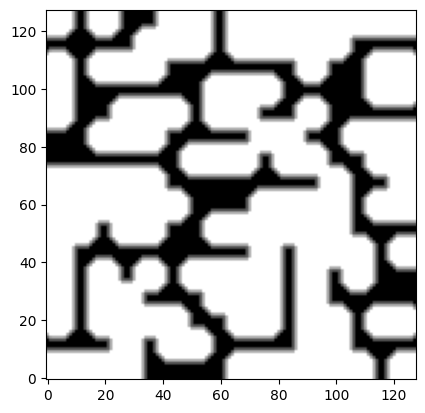

In [23]:
df = pd.read_csv(f'../working/mixer_{size}/topology_1.dat')
example = df['lambda'].to_numpy().reshape(size, size)
plt.imshow(example, cmap='gray', origin='lower')

In [24]:
dataset_dir = f'../working/mixer_{size}'
height = width = size

files = os.listdir(dataset_dir)
files = [f for f in files if f.endswith('.dat')]
files.sort()

coords_file = pd.read_csv(f'../working/coordinates_128.csv')

inputs = []
outputs = []
for f in files[:11]:
    print(f)
    df = pd.read_csv(f'{dataset_dir}/{f}').drop(columns=['cellI'])
    df['x'] = coords_file['x']
    df['y'] = coords_file['y']
    df['z'] = coords_file['z']
    df = df.to_numpy().T.reshape(-1, height, width)
    inputs.append(df[4:])
    outputs.append(df[0:4])

topology_0.dat
topology_1.dat
topology_10.dat
topology_100.dat
topology_101.dat
topology_102.dat
topology_103.dat
topology_104.dat
topology_105.dat
topology_106.dat
topology_107.dat


In [25]:
np.array(inputs).shape, np.array(outputs).shape

((11, 4, 128, 128), (11, 4, 128, 128))

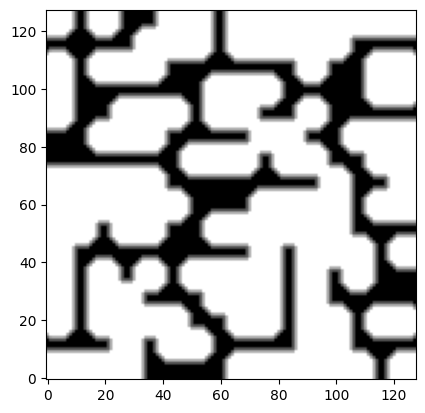

In [26]:
plt.imshow(inputs[1][0], cmap='gray', origin='lower')

In [27]:
coords_array = coords_file.drop(columns=['cellI']).to_numpy()

In [28]:
coords_array.shape

(16384, 4)

In [29]:
coords_array

array([[5.000e-04, 5.000e-04, 1.000e-03, 2.000e-09],
       [1.500e-03, 5.000e-04, 1.000e-03, 2.000e-09],
       [2.500e-03, 5.000e-04, 1.000e-03, 2.000e-09],
       ...,
       [1.255e-01, 1.275e-01, 1.000e-03, 2.000e-09],
       [1.265e-01, 1.275e-01, 1.000e-03, 2.000e-09],
       [1.275e-01, 1.275e-01, 1.000e-03, 2.000e-09]], shape=(16384, 4))

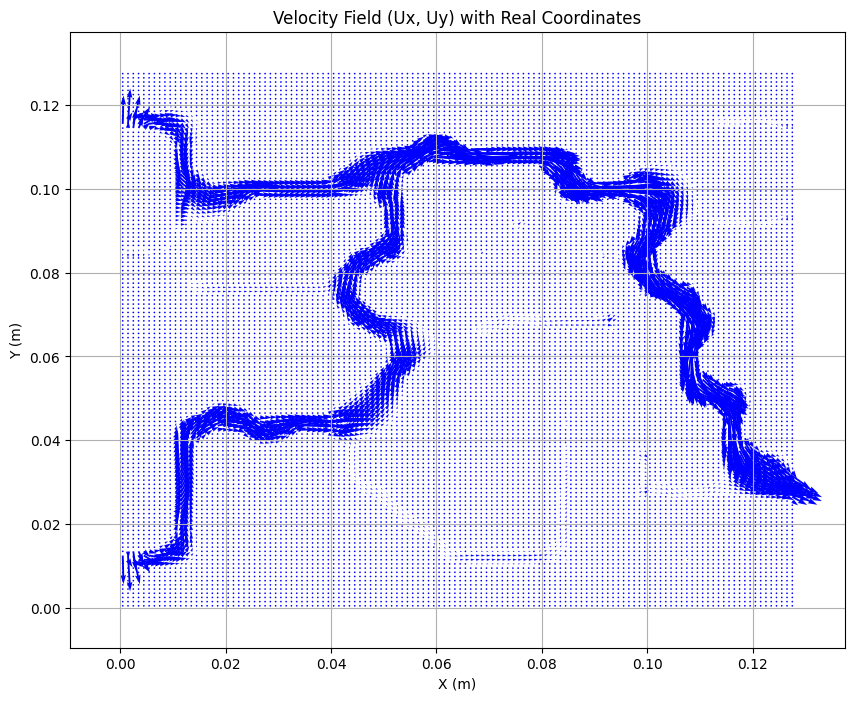

In [30]:
plot_quiver(outputs[1], coords_array, quiver_scale=1e2)

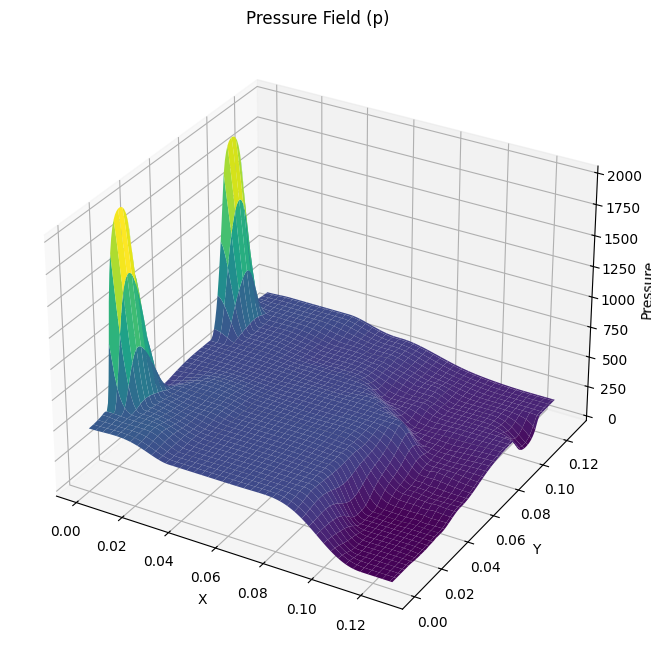

In [31]:
plot_pressure(outputs[1], coords_array)

In [8]:
# Save
# inputs = np.array(inputs)
# outputs = np.array(outputs)
# np.savez('../data/mixer_128.npz', inputs=inputs, outputs=outputs)

In [2]:
data = np.load('../data/mixer_64.npz')
print(data['inputs'].shape, data['outputs'].shape)

(550, 1, 64, 64) (550, 4, 64, 64)


In [3]:
x, y = data['inputs'][:5], data['outputs'][:5]
print(x.shape, y.shape)

(5, 4, 256, 256) (5, 4, 256, 256)


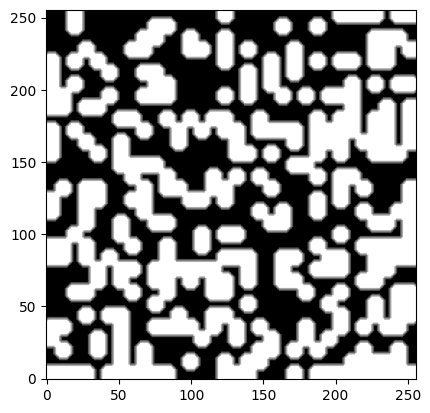

In [13]:
plt.imshow(x[1, 0], cmap='gray', origin='lower')

In [7]:
coords_array = pd.read_csv(f'../working/coordinates_128.csv').to_numpy()
coords_array

array([[0.0000e+00, 5.0000e-04, 5.0000e-04, 1.0000e-03, 2.0000e-09],
       [1.0000e+00, 1.5000e-03, 5.0000e-04, 1.0000e-03, 2.0000e-09],
       [2.0000e+00, 2.5000e-03, 5.0000e-04, 1.0000e-03, 2.0000e-09],
       ...,
       [1.6381e+04, 1.2550e-01, 1.2750e-01, 1.0000e-03, 2.0000e-09],
       [1.6382e+04, 1.2650e-01, 1.2750e-01, 1.0000e-03, 2.0000e-09],
       [1.6383e+04, 1.2750e-01, 1.2750e-01, 1.0000e-03, 2.0000e-09]],
      shape=(16384, 5))

In [17]:
coords = data['inputs'][0, -3:, :, :].reshape(3, -1).T
coords

array([[0.00025, 0.00025, 0.001  ],
       [0.00075, 0.00025, 0.001  ],
       [0.00125, 0.00025, 0.001  ],
       ...,
       [0.12675, 0.12775, 0.001  ],
       [0.12725, 0.12775, 0.001  ],
       [0.12775, 0.12775, 0.001  ]], shape=(65536, 3))

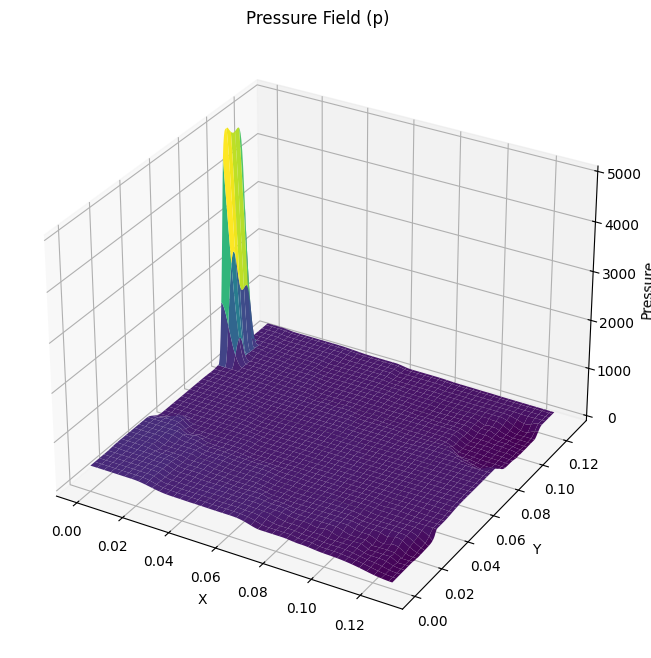

In [18]:
plot_pressure(np.clip(data['outputs'][1], 0, 5000), coords)

In [ ]:
# Prepare test data
dataset_dir = '../data/mixer_64_test'
height = width = 64

files = os.listdir(dataset_dir)
files = [f for f in files if f.endswith('.dat')]
files.sort()

coords_file = pd.read_csv(f'{dataset_dir}/coordinates.csv')

inputs = []
outputs = []
for f in files:
    print(f)
    df = pd.read_csv(f'{dataset_dir}/{f}').drop(columns=['cellI'])
    df['x'] = coords_file['x']
    df['y'] = coords_file['y']
    df['z'] = coords_file['z']
    df = df.to_numpy().T.reshape(-1, height, width)
    inputs.append(df[4:])
    outputs.append(df[0:4])
    
np.array(inputs).shape, np.array(outputs).shape

In [ ]:
# Save
inputs = np.array(inputs)
outputs = np.array(outputs)
np.savez('../data/mixer_64_test.npz', inputs=inputs, outputs=outputs)

In [ ]:
# Check for matches in inputs with training data
train_data = np.load('../data/mixer_64.npz')
test_data = np.load('../data/mixer_64_test.npz')
train_inputs = train_data['inputs']
test_inputs = test_data['inputs']

matches = []
for i, test_input in enumerate(test_inputs):
    for j, train_input in enumerate(train_inputs):
        if np.array_equal(test_input, train_input):
            matches.append((i, j))
            print(f'Test sample {i} matches Train sample {j}')

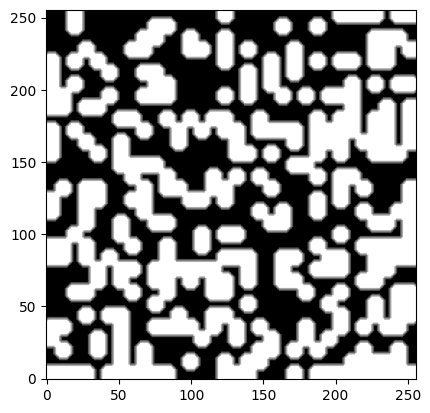

In [28]:
# Find a specific topology in the training data
target_file = '../working/mixer_256/topology_1.dat'
target_df = pd.read_csv(target_file)
target_array = target_df['lambda'].to_numpy().reshape(256, 256)
plt.imshow(target_array, cmap='gray', origin='lower')

In [2]:
topologies = pd.read_csv('../working/topologies_32x32.csv', header=None)

In [4]:
topologies.iloc[108]

0        True
1       False
2       False
3        True
4       False
        ...  
1019     True
1020    False
1021    False
1022    False
1023     True
Name: 108, Length: 1024, dtype: bool

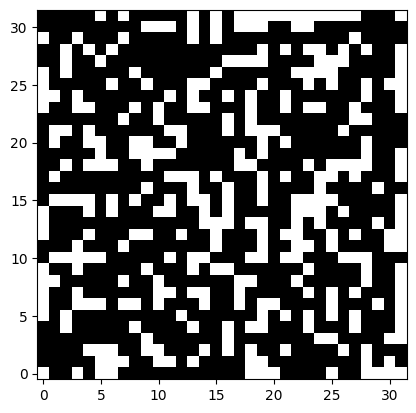

In [3]:
topology_array = topologies.iloc[108].to_numpy().reshape(32, 32)
# print(topology_array)
    
plt.imshow(topology_array, cmap='gray', origin='lower')

In [12]:
def total_pressure(topo_array):
    Ux, Uy, Uz, p = topo_array
    return np.sum(p)

data = np.load('../data/mixer_128_test.npz')
print(data['inputs'].shape, data['outputs'].shape)
pressures = []
for i in range(data['outputs'].shape[0]):
    pressures.append((i, total_pressure(data['outputs'][i])))
    
sorted(pressures, key=lambda x: x[1], reverse=True)[:10]

(871, 1, 128, 128) (871, 4, 128, 128)


KeyboardInterrupt: 

In [11]:
np.mean(pressures, axis=0)

array([4.35000000e+02, 2.40828089e+06])

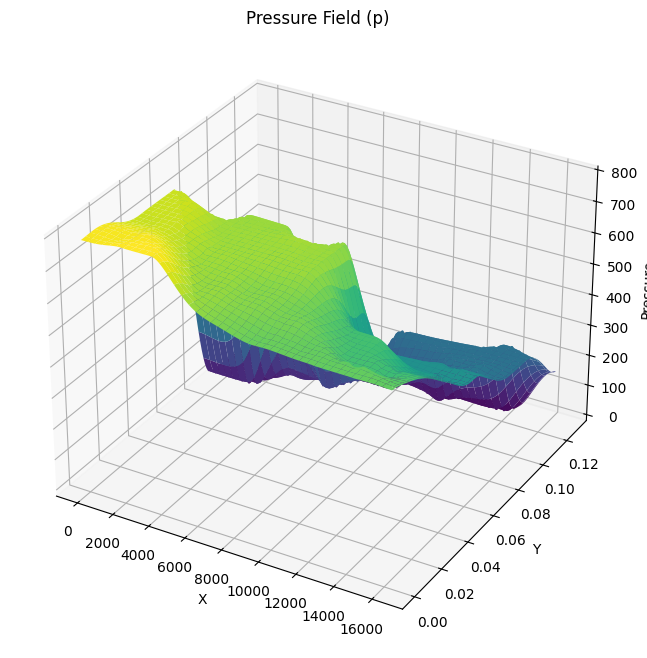

In [8]:
plot_pressure(data['outputs'][714], coords_array)

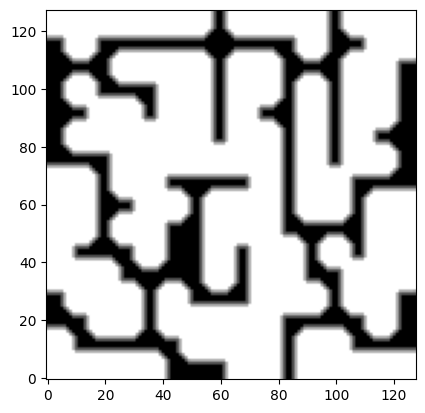

In [9]:
plt.imshow(data['inputs'][714][0], cmap='gray', origin='lower')

In [19]:
from PIL import Image
import cv2

wannafind = inputs[10][0]


def match_bitmaps(img32, img256):
    small = cv2.resize(img256, (32, 32), interpolation=cv2.INTER_AREA)
    return np.linalg.norm(img32.astype(np.float32) - small.astype(np.float32))


distances = []
for i in range(topologies.shape[0]):
    topo_array = topologies.iloc[i].to_numpy().reshape(32, 32)
    dist = match_bitmaps(topo_array, wannafind)
    print(i, dist)
    distances.append((i, dist))
    
print(min(distances, key=lambda x: x[1]))

0 19.716936
1 19.174805
2 20.06538
3 19.40281
4 19.468493
5 19.467224
6 19.957117
7 19.374674
8 19.678524
9 19.487383
10 19.569288
11 19.669569
12 19.609062
13 19.969446
14 20.101402
15 20.023653
16 19.97512
17 19.601772
18 20.140606
19 19.84514
20 19.642872
21 19.51482
22 19.833473
23 19.588526
24 20.200378
25 19.796154
26 20.064915
27 19.794548
28 19.112968
29 19.591866
30 20.102127
31 20.188364
32 19.464588
33 19.861277
34 19.797108
35 19.71077
36 19.859785
37 19.686264
38 20.097378
39 19.81457
40 19.156061
41 20.017733
42 19.24375
43 19.493153
44 19.57463
45 20.07385
46 19.591278
47 19.574047
48 20.092121
49 19.59115
50 19.212263
51 19.244064
52 19.93721
53 19.227285
54 19.887741
55 20.07001
56 19.75623
57 19.682932
58 19.922165
59 19.781473
60 19.594788
61 19.694954
62 19.940321
63 19.48212
64 20.657377
65 19.600645
66 19.861607
67 19.62286
68 19.836945
69 19.664429
70 19.73066
71 19.781075
72 19.831738
73 19.75933
74 19.64213
75 19.694107
76 19.629732
77 19.886698
78 20.168314
79